# 第 16 章数学直觉实验
全部数值与函数为原创教学设定，不对应真实用户或训练任务。先运行 examples/math_experiments.py 生成配图。

NumPy 2.3.5
均值 方差 标准差 20.0 2.6666666666666665 1.632993161855452
均值 方差 标准差 20.0 66.66666666666667 8.16496580927726


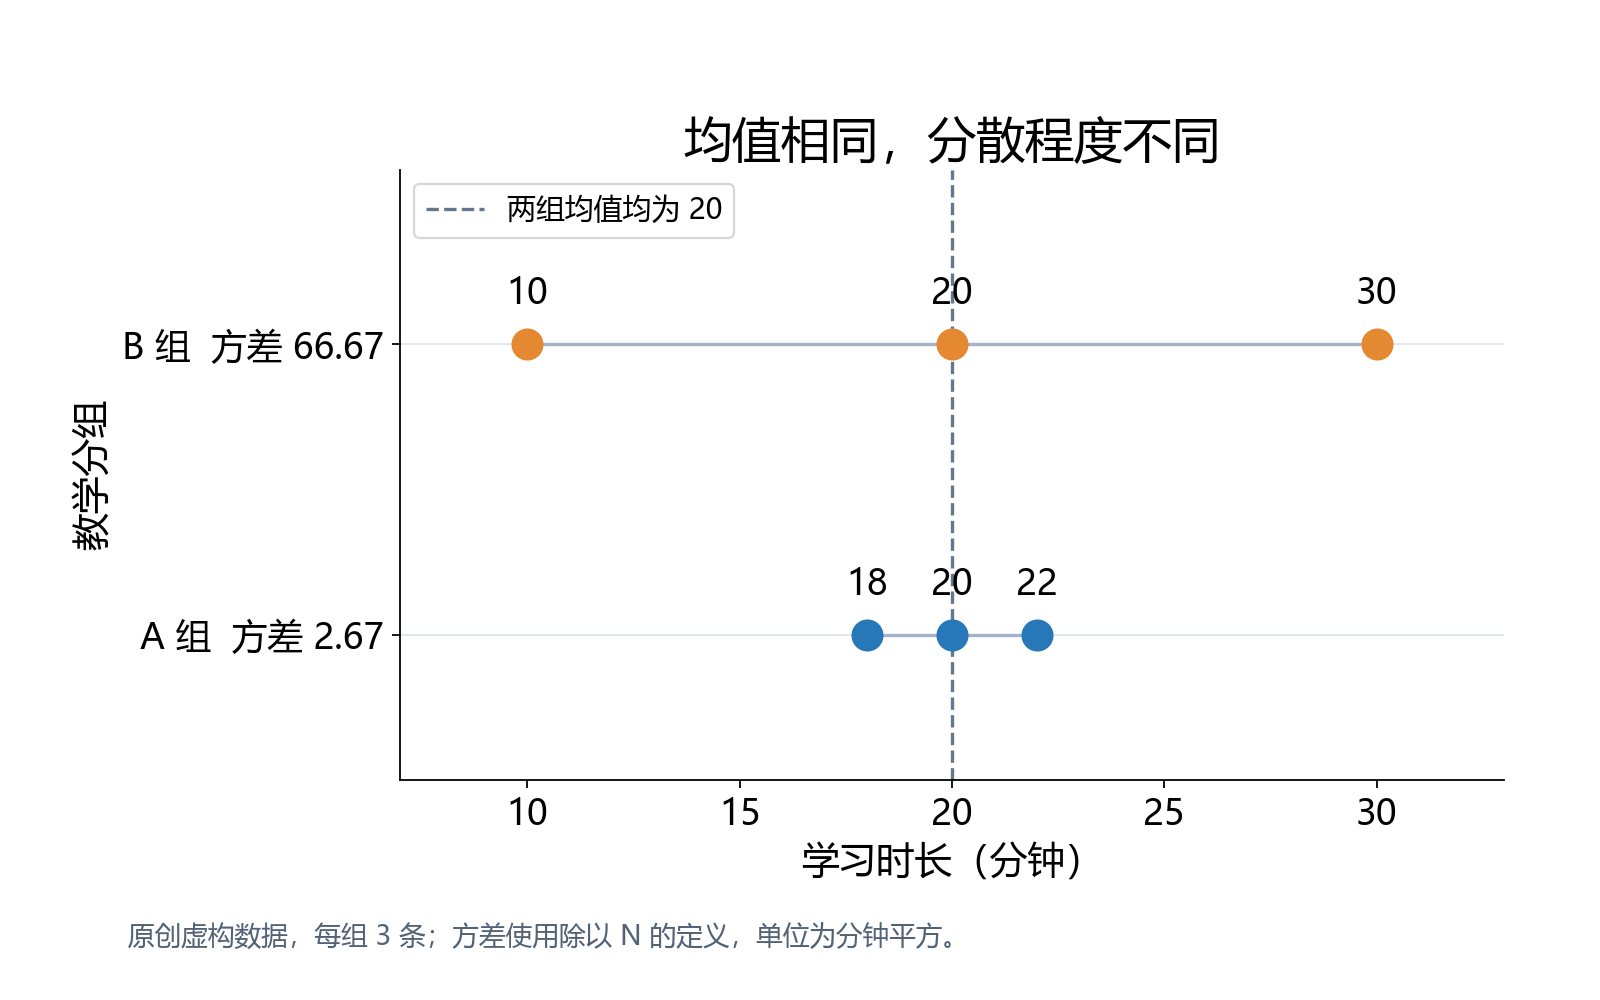

In [1]:
import numpy as np
from examples.math_core import loss, gradient, descent, finite_difference
from IPython.display import Image, display
print('NumPy', np.__version__)
a = np.array([18, 20, 22])
b = np.array([10, 20, 30])
for values in [a, b]:
    print('均值 方差 标准差', values.mean(), values.var(ddof=0), values.std(ddof=0))
display(Image(filename='assets/mean-variance.png'))

## 方差的两种分母
本章描述手头三条记录，除以 N。若用样本估计总体方差，常用 N-1，不能混写。

In [2]:
print('A组 ddof0', a.var(ddof=0))
print('A组 ddof1', a.var(ddof=1))
np.testing.assert_allclose([a.var(ddof=0), a.var(ddof=1)], [8/3, 4])

A组 ddof0 2.6666666666666665
A组 ddof1 4.0


## 公平骰子的假设
六个点数等可能，偶数事件有三个结果。概率为三个 1/6 相加。

概率总和 0.9999999999999999
偶数概率 0.5


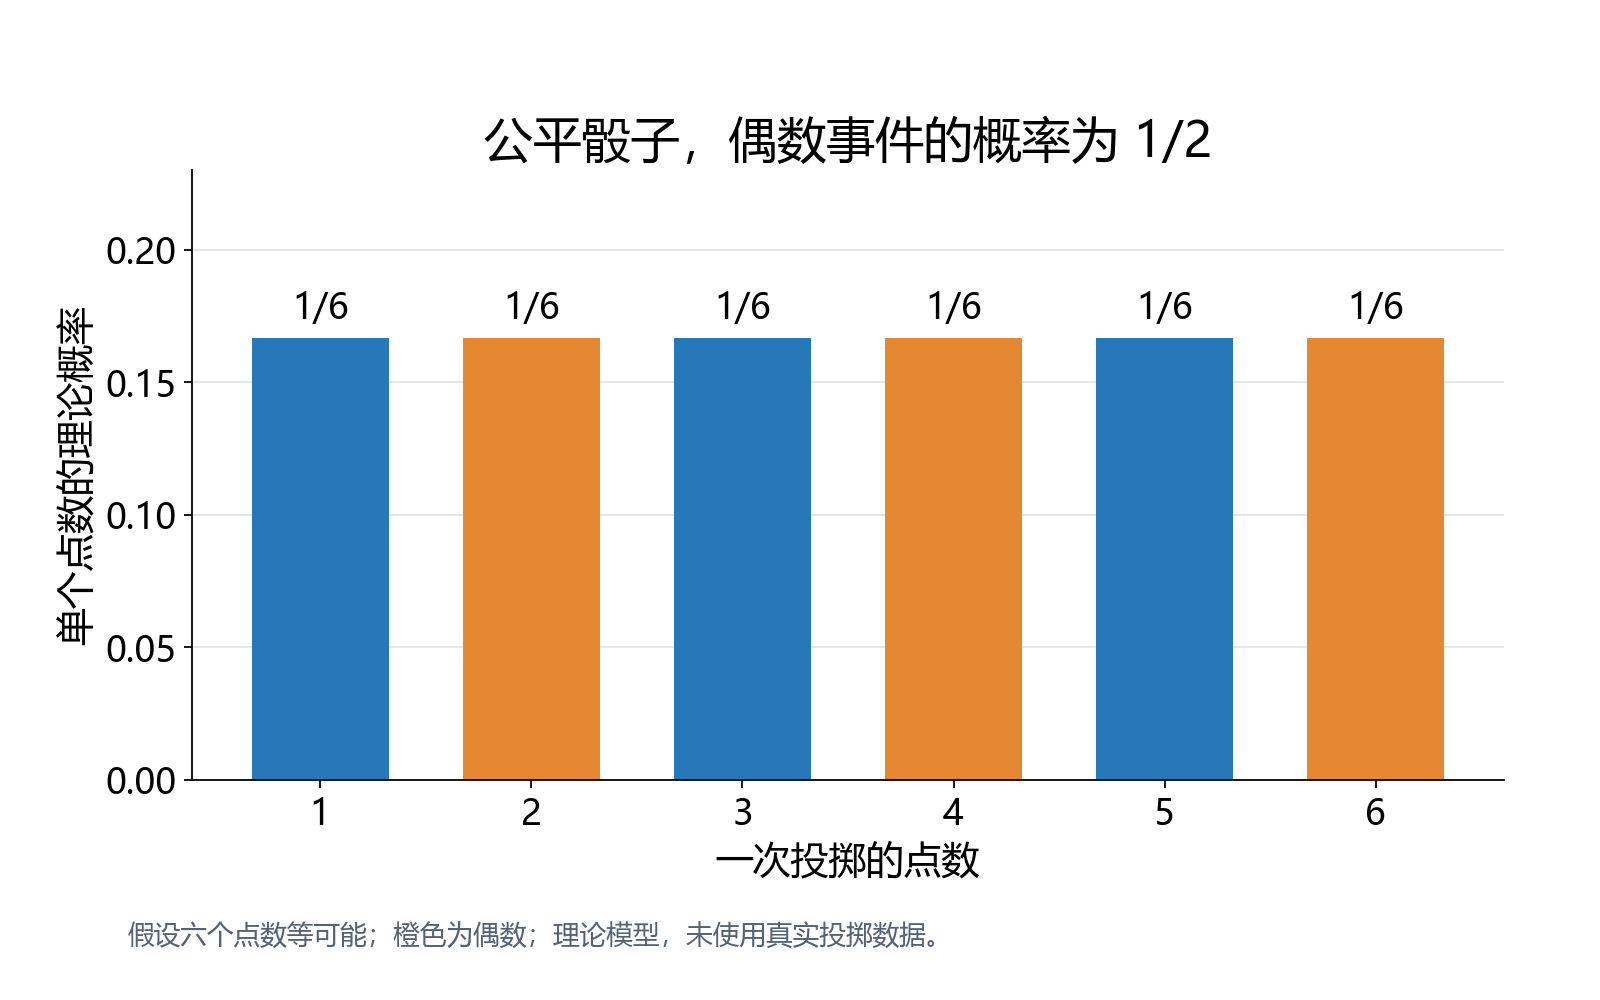

In [3]:
probabilities = np.full(6, 1/6)
print('概率总和', probabilities.sum())
print('偶数概率', probabilities[[1, 3, 5]].sum())
display(Image(filename='assets/probability.png'))

## 先读曲线，再读导数
L(w)=(w-3)^2+1，梯度为 2(w-3)。

w 损失 梯度 1 5.0 -4.0
w 损失 梯度 3 1.0 0.0
w 损失 梯度 5 5.0 4.0
w 损失 梯度 9 37.0 12.0
h 与中心差分 0.1 3.999999999999986
h 与中心差分 0.01 3.9999999999999147
h 与中心差分 0.001 4.000000000001336


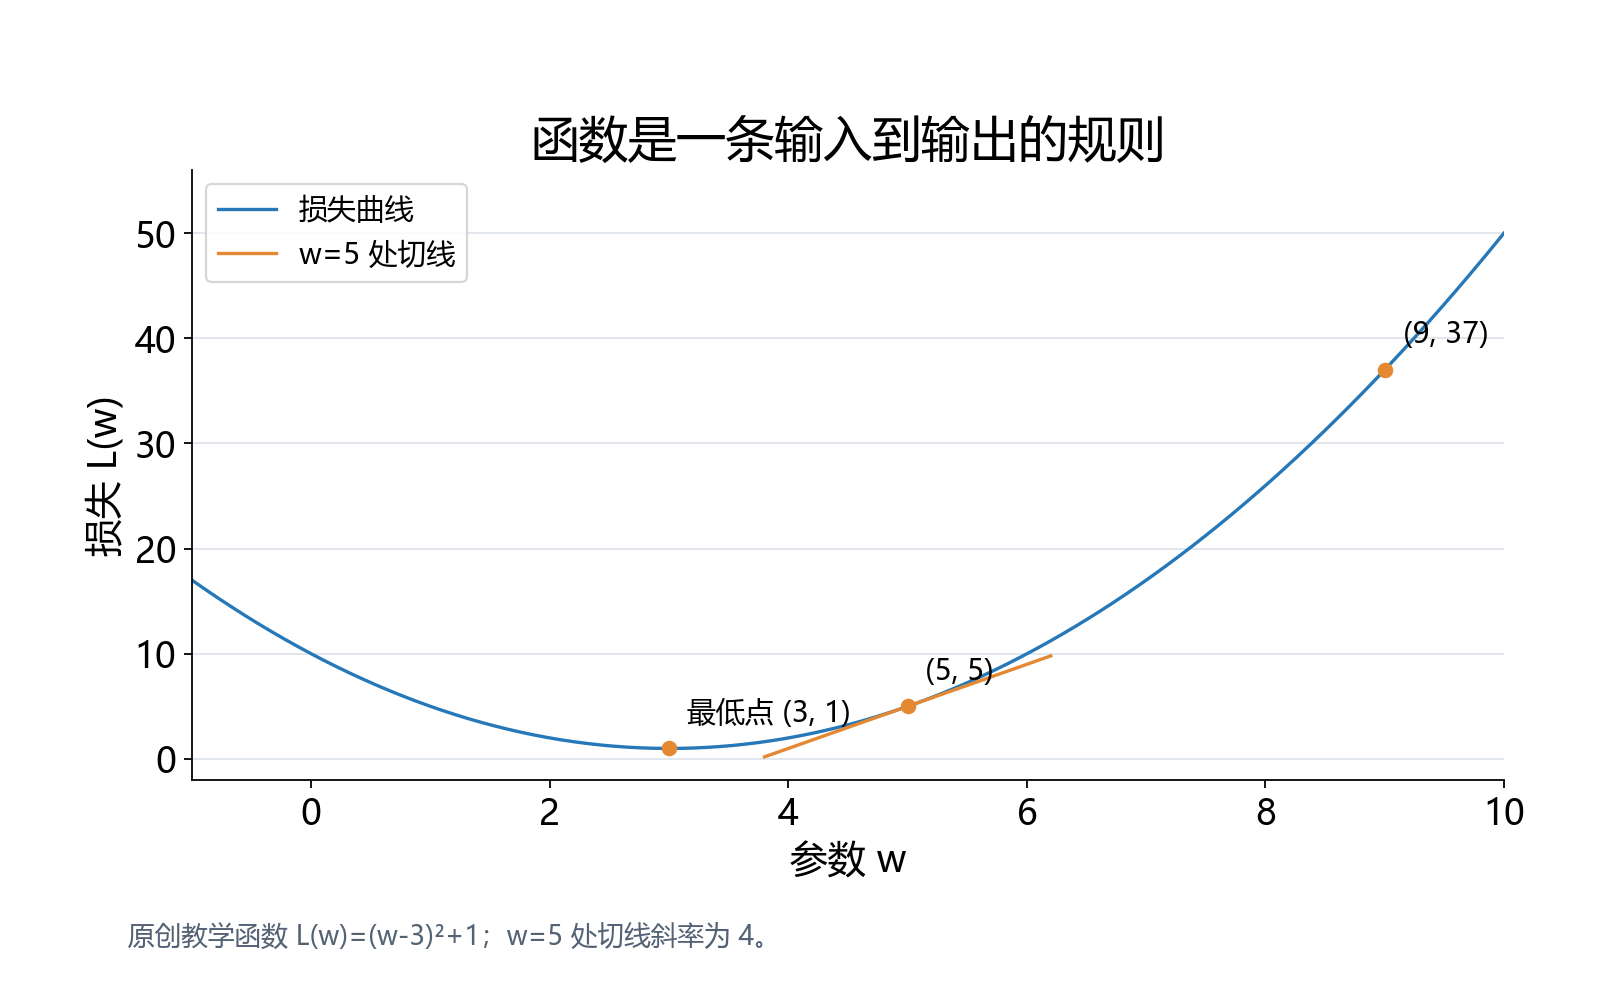

In [4]:
for w in [1, 3, 5, 9]:
    print('w 损失 梯度', w, loss(w), gradient(w))
for h in [0.1, 0.01, 0.001]:
    print('h 与中心差分', h, finite_difference(5, h))
display(Image(filename='assets/function-derivative.png'))

## 每一步都重算梯度
先算当前位置损失和梯度，再按学习率更新 w，最后核对新损失。编号 0 未更新。

In [5]:
history = descent(9, 0.2, 12)
for row in history[:4] + history[-1:]:
    print(f"第 {row['step']} 步 w={row['w']:.6f} loss={row['loss']:.6f} gradient={row['gradient']:.6f}")
assert all(b['loss'] < a['loss'] for a, b in zip(history, history[1:]))

第 0 步 w=9.000000 loss=37.000000 gradient=12.000000
第 1 步 w=6.600000 loss=13.960000 gradient=7.200000
第 2 步 w=5.160000 loss=5.665600 gradient=4.320000
第 3 步 w=4.296000 loss=2.679616 gradient=2.592000
第 12 步 w=3.013061 loss=1.000171 gradient=0.026121


## 大步、小步和振荡
这里只比较同一个二次函数，不把学习率范围推广到所有模型。

学习率 第1步损失 第12步损失 0.01 35.5744 23.168092
学习率 第1步损失 第12步损失 0.2 13.96 1.000171
学习率 第1步损失 第12步损失 0.5 1.0 1.0
学习率 第1步损失 第12步损失 1.0 37.0 37.0
学习率 第1步损失 第12步损失 1.1 52.84 2862.886499


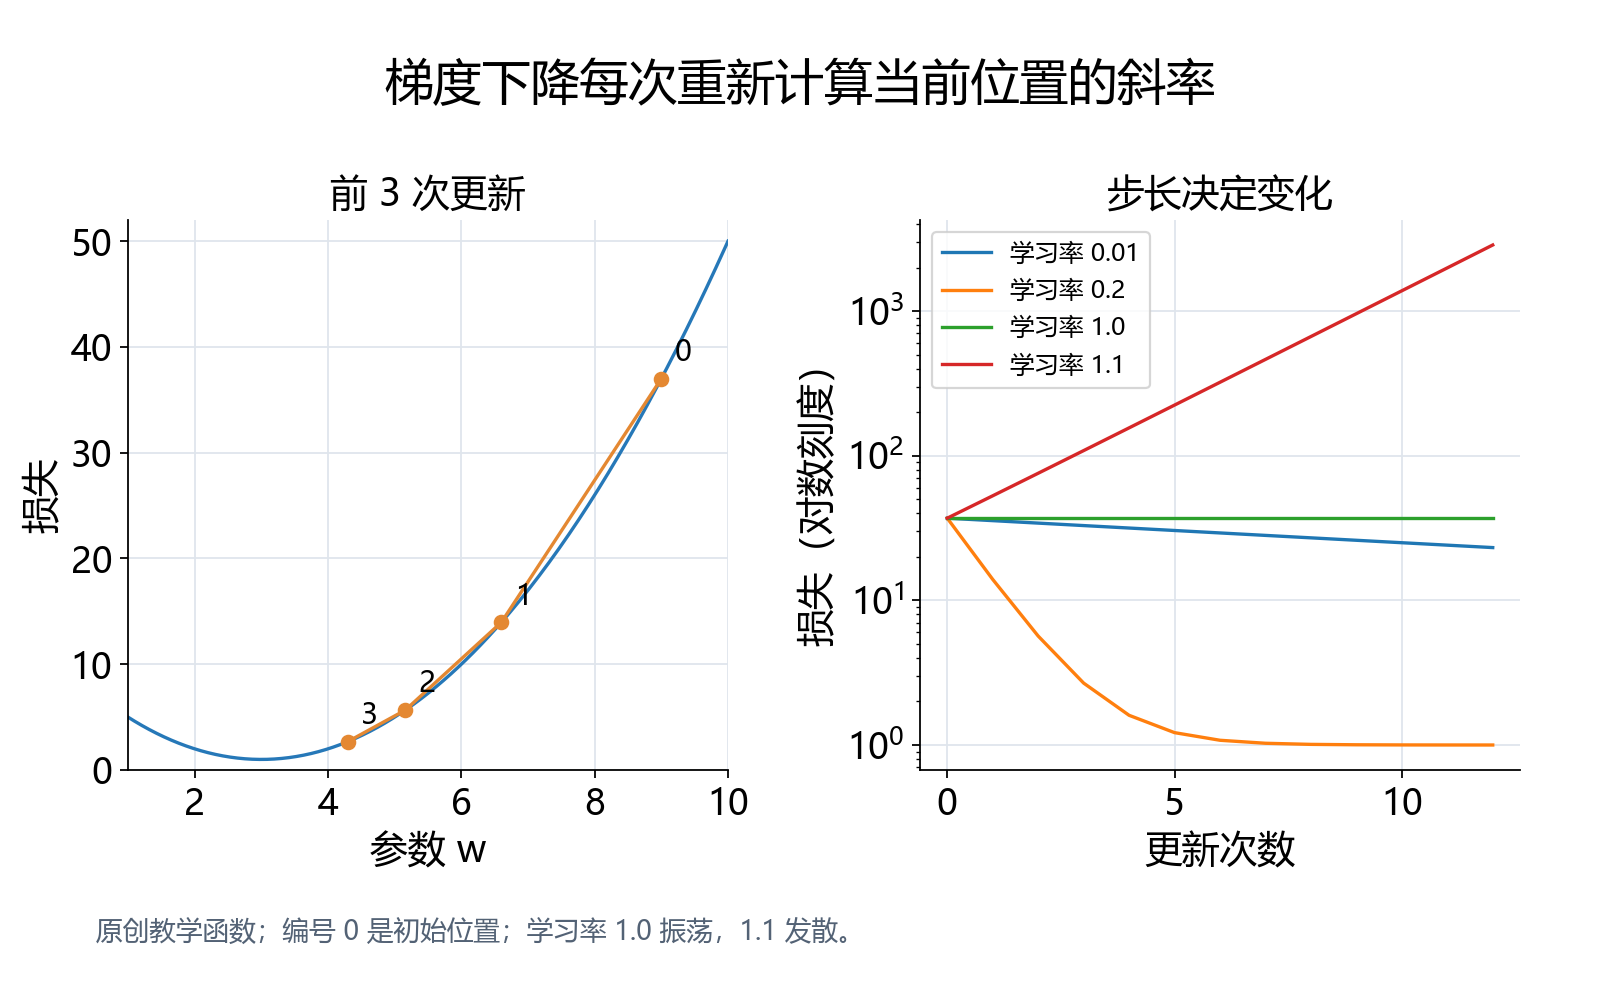

In [6]:
for rate in [0.01, 0.2, 0.5, 1.0, 1.1]:
    rows = descent(9, rate, 12)
    print('学习率 第1步损失 第12步损失', rate, round(rows[1]['loss'], 6), round(rows[-1]['loss'], 6))
display(Image(filename='assets/gradient-descent.png'))

## 独立练习
从 w=1 出发，学习率 0.25。先手算，再核对两次更新。

In [7]:
practice = descent(1, 0.25, 2)
print([(row['w'], row['loss']) for row in practice])
np.testing.assert_allclose([row['w'] for row in practice], [1, 2, 2.5])

[(1.0, 5.0), (2.0, 2.0), (2.5, 1.25)]
